# eGRID 2023 Deep Learning Project Pipeline

This notebook implements the full project workflow for plant-level CO₂ intensity prediction and scenario analysis using the EPA eGRID 2023 `PLNT23` sheet. It follows the project direction in the proposal by combining deep learning architectures with baseline machine-learning models and comparative evaluation.

## Workflow

- Load and clean the plant-level eGRID table from `PLNT23`.
- Engineer resource-mix and operational features from available plant variables.
- Train baseline models for comparison, which is explicitly allowed alongside deep learning in the project template.
- Train deep tabular models including an MLP and residual MLP, with an optional transformer-style fuel-token model to satisfy the proposal's advanced-model direction.
- Evaluate performance overall and by plant subgroup, then run counterfactual scenario analysis based on fuel mix and CHP settings reflected in the eGRID variables.

In [1]:
import os
import json
import math
import random
from dataclasses import dataclass
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
CONFIG = {
    "excel_path": "egrid-2023-data.xlsx",
    "sheet_name": "PLNT23",
    "target_col": "Plant annual CO2 total output emission rate (lb/MWh)",
    "alt_target_cols": [
        "Plant annual CO2 input emission rate (lb/MMBtu)",
        "Plant annual CO2 equivalent total output emission rate (lb/MWh)",
    ],
    "id_cols": [
        "Plant name",
        "DOE/EIA ORIS plant or facility code",
        "Plant state abbreviation",
        "eGRID subregion acronym",
        "Plant primary fuel category",
    ],
    "cat_cols": [
        "Plant state abbreviation",
        "Plant-level sector",
        "Balancing Authority Code",
        "NERC region acronym",
        "eGRID subregion acronym",
        "eGRID subregion name",
        "Plant associated ISO/RTO Territory",
        "Plant primary fuel",
        "Plant primary fuel category",
        "Combined heat and power (CHP) plant adjustment flag",
        "Plant pumped storage flag",
        "Flag indicating if the plant burned or generated any amount of coal",
    ],
    "num_cols": [
        "Number of units",
        "Number of generators",
        "Plant latitude",
        "Plant longitude",
        "Plant capacity factor",
        "Plant nameplate capacity (MW)",
        "Nonbaseload Factor",
        "CHP plant useful thermal output (MMBtu)",
        "CHP plant power to heat ratio",
        "CHP plant electric allocation factor",
        "Plant annual heat input from combustion (MMBtu)",
        "Plant total annual heat input (MMBtu)",
        "Plant annual net generation (MWh)",
        "Plant annual nonbaseload generation (MWh)",
        "Plant annual CO2 emissions (tons)",
        "Plant annual CH4 emissions (lbs)",
        "Plant annual N2O emissions (lbs)",
        "Plant annual CO2 equivalent emissions (tons)",
        "Plant nominal heat rate (Btu/kWh)",
        "Plant annual coal net generation (MWh)",
        "Plant annual oil net generation (MWh)",
        "Plant annual gas net generation (MWh)",
        "Plant annual nuclear net generation (MWh)",
        "Plant annual hydro net generation (MWh)",
        "Plant annual biomass net generation (MWh)",
        "Plant annual wind net generation (MWh)",
        "Plant annual solar net generation (MWh)",
        "Plant annual geothermal net generation (MWh)",
        "Plant annual other fossil net generation (MWh)",
        "Plant annual other unknown/ purchased fuel net generation (MWh)",
        "Plant annual total nonrenewables net generation (MWh)",
        "Plant annual total renewables net generation (MWh)",
        "Plant annual total nonhydro renewables net generation (MWh)",
        "Plant annual total combustion net generation (MWh)",
        "Plant annual total noncombustion net generation (MWh)",
        "Plant coal generation percent (resource mix)",
        "Plant oil generation percent (resource mix)",
        "Plant gas generation percent (resource mix)",
        "Plant nuclear generation percent (resource mix)",
        "Plant hydro generation percent (resource mix)",
        "Plant biomass generation percent (resource mix)",
        "Plant wind generation percent (resource mix)",
        "Plant solar generation percent (resource mix)",
        "Plant geothermal generation percent (resource mix)",
        "Plant other fossil generation percent (resource mix)",
        "Plant other unknown / purchased fuel generation percent (resource mix)",
        "Plant total nonrenewables generation percent (resource mix)",
        "Plant total renewables generation percent (resource mix)",
        "Plant total nonhydro renewables generation percent (resource mix)",
        "Plant total combustion generation percent (resource mix)",
        "Plant total noncombustion generation percent (resource mix)",
    ],
    "batch_size": 256,
    "epochs": 60,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "dropout": 0.15,
    "hidden_dim": 256,
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "output_dir": "output/egrid_project_outputs",
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(CONFIG["device"])

cuda


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def choose_existing_cols(df, cols):
    return [c for c in cols if c in df.columns]


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def metrics_dict(y_true, y_pred):
    return {
        "rmse": rmse(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def clean_data(df, target_col):
    df = df.copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df[df[target_col].notna()].copy()
    if "Plant annual net generation (MWh)" in df.columns:
        df = df[df["Plant annual net generation (MWh)"].fillna(0) >= 0].copy()
    return df


def add_engineered_features(df):
    df = df.copy()
    g = df.get("Plant annual net generation (MWh)")
    if g is not None:
        g = g.replace(0, np.nan)
        pairs = [
            ("Plant annual total noncombustion net generation (MWh)", "derived_noncombustion_share"),
            ("Plant annual total combustion net generation (MWh)", "derived_combustion_share"),
            ("Plant annual total renewables net generation (MWh)", "derived_renewables_share"),
            ("Plant annual total nonrenewables net generation (MWh)", "derived_nonrenewables_share"),
            ("Plant annual gas net generation (MWh)", "derived_gas_share"),
            ("Plant annual coal net generation (MWh)", "derived_coal_share"),
            ("Plant annual solar net generation (MWh)", "derived_solar_share"),
            ("Plant annual wind net generation (MWh)", "derived_wind_share"),
            ("Plant annual nuclear net generation (MWh)", "derived_nuclear_share"),
            ("Plant annual hydro net generation (MWh)", "derived_hydro_share"),
        ]
        for src, new in pairs:
            if src in df.columns:
                df[new] = df[src] / g
    if {"Plant annual heat input from combustion (MMBtu)", "Plant annual net generation (MWh)"}.issubset(df.columns):
        denom = df["Plant annual net generation (MWh)"].replace(0, np.nan)
        df["derived_heat_input_per_mwh"] = df["Plant annual heat input from combustion (MMBtu)"] / denom
    if {"Plant annual CO2 emissions (tons)", "Plant annual net generation (MWh)"}.issubset(df.columns):
        denom = df["Plant annual net generation (MWh)"].replace(0, np.nan)
        df["derived_co2_tons_per_mwh"] = df["Plant annual CO2 emissions (tons)"] / denom
    if {"Plant annual CO2 equivalent emissions (tons)", "Plant annual net generation (MWh)"}.issubset(df.columns):
        denom = df["Plant annual net generation (MWh)"].replace(0, np.nan)
        df["derived_co2e_tons_per_mwh"] = df["Plant annual CO2 equivalent emissions (tons)"] / denom
    return df


seed_everything(CONFIG["seed"])

## Load and inspect data

The notebook uses the `PLNT23` sheet because that is the eGRID plant-level table containing plant identity, fuel mix, operational characteristics, emissions, and emissions-rate variables needed for the proposal’s input/output structure.[file:1]

In [5]:
df = pd.read_excel("egrid 2023 data.xlsx", sheet_name=CONFIG["sheet_name"])
print(df.shape)
df.head()

(12613, 150)


,Plant file sequence number,Data Year,Plant state abbreviation,Plant name,DOE/EIA ORIS plant or facility code,Plant transmission or distribution system owner name,Plant transmission or distribution system owner ID,Utility name,Utility ID,Plant-level sector,...,Plant geothermal generation percent (resource mix),Plant other fossil generation percent (resource mix),Plant other unknown / purchased fuel generation percent (resource mix),Plant total nonrenewables generation percent (resource mix),Plant total renewables generation percent (resource mix),Plant total nonrenewables other unknown/purchased generation percent (resource mix),Plant total nonhydro renewables generation percent (resource mix),Plant total combustion generation percent (resource mix),Plant total noncombustion generation percent (resource mix),Plant total noncombustion other unknown/purchased generation percent (resource mix)
0,SEQPLT23,YEAR,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,SECTOR,...,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTOPR,PLTHPR,PLCYPR,PLCNPR,PLCOPR
1,1,2023,AK,Alakanuk,57053,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2023,AK,Allison Creek Hydro,58982,"Copper Valley Elec Assn, Inc",4329,"Copper Valley Elec Assn, Inc",4329,Electric Utility,...,0,0,0,0,1,0,0,0,1,0
3,3,2023,AK,Ambler,60243,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,0,0,0,1,0,0,0,1,0,0
4,4,2023,AK,Angoon,7462,"Inside Passage Elec Coop, Inc",18963,"Inside Passage Elec Coop, Inc",18963,Electric Utility,...,0,0,0,1,0,0,0,1,0,0


In [7]:
df = df.iloc[1:].copy()
df = clean_data(df, CONFIG["target_col"])
df = add_engineered_features(df)
engineered = [c for c in df.columns if c.startswith("derived_")]
num_cols = choose_existing_cols(df, CONFIG["num_cols"] + engineered)
cat_cols = choose_existing_cols(df, CONFIG["cat_cols"])
id_cols = choose_existing_cols(df, CONFIG["id_cols"])

print("Rows after cleaning:", df.shape[0])
print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))
print("Target:", CONFIG["target_col"])

Rows after cleaning: 3274
Numeric features: 64
Categorical features: 12
Target: Plant annual CO2 total output emission rate (lb/MWh)


/tmp/ipykernel_5084/355320899.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace([np.inf, -np.inf], np.nan)


In [8]:
summary = df[[CONFIG["target_col"]] + num_cols[:8]].describe().T
summary.head(15)

,count,mean,std,min,25%,50%,75%,max
Plant annual CO2 total output emission rate (lb/MWh),3274.0,1.595043e+03,8.745695e+03,0.000000,615.056000,1133.539500,1.682829e+03,4.235040e+05
Number of units,3274.0,3.616982e+00,3.721175e+00,1.000000,2.000000,3.000000,4.000000e+00,4.800000e+01
Number of generators,3274.0,3.749236e+00,3.728452e+00,1.000000,2.000000,3.000000,4.000000e+00,4.800000e+01
Plant latitude,3274.0,3.851420e+01,6.715475e+00,17.947115,33.998600,39.276789,4.187170e+01,7.129200e+01
Plant longitude,3274.0,-9.443234e+01,1.862722e+01,-171.712439,-100.869625,-91.231000,-8.120243e+01,-6.527956e+01
Plant capacity factor,3274.0,2.868417e-01,2.820301e-01,0.000010,0.016025,0.197275,5.256975e-01,1.059290e+00
Plant nameplate capacity (MW),3274.0,2.554620e+02,4.793464e+02,0.800000,6.000000,36.200000,2.746500e+02,4.263000e+03
Nonbaseload Factor,3180.0,7.320337e-01,3.435334e-01,0.000000,0.462337,1.000000,1.000000e+00,1.000000e+00
CHP plant useful thermal output (MMBtu),788.0,2.516840e+06,4.242590e+06,0.000000,79830.200000,563200.000000,2.695802e+06,2.560507e+07


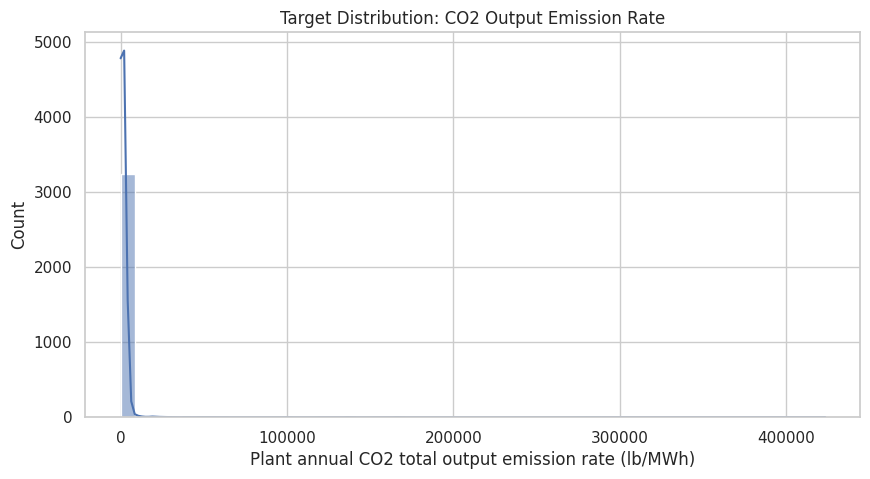

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df[CONFIG["target_col"]].dropna(), bins=50, kde=True)
plt.title("Target Distribution: CO2 Output Emission Rate")
plt.xlabel(CONFIG["target_col"])
plt.show()

## Train/validation/test split

The model comparison is structured around a holdout test split plus a validation split for deep-learning training, which supports the expectation for clear evaluation metrics and comparative analysis.

In [10]:
X = df[num_cols + cat_cols].copy()
y = df[CONFIG["target_col"]].astype(float).to_numpy()

X_train_full, X_test, y_train_full, y_test, idx_train_full, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=CONFIG["seed"]
)
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_train_full, y_train_full, idx_train_full, test_size=0.2, random_state=CONFIG["seed"]
)

df_train = df.loc[idx_train].copy()
df_val = df.loc[idx_val].copy()
df_test = df.loc[idx_test].copy()

print(X_train.shape, X_val.shape, X_test.shape)

(2095, 76) (524, 76) (655, 76)


## Baseline models

Traditional machine-learning baselines are included because the project template allows them for comparison, while still requiring that the core project use deep learning architectures.

In [11]:
def build_sklearn_baselines(num_cols, cat_cols):
    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ])
    models = {
        "gradient_boosting": Pipeline([
            ("pre", pre),
            ("model", GradientBoostingRegressor(random_state=CONFIG["seed"]))
        ]),
        "random_forest": Pipeline([
            ("pre", pre),
            ("model", RandomForestRegressor(n_estimators=300, random_state=CONFIG["seed"], n_jobs=-1))
        ])
    }
    return models


baseline_models = build_sklearn_baselines(num_cols, cat_cols)
baseline_results = []
for name, model in baseline_models.items():
    model.fit(X_train_full, y_train_full)
    pred = model.predict(X_test)
    m = metrics_dict(y_test, pred)
    m["model"] = name
    baseline_results.append(m)

baseline_results = pd.DataFrame(baseline_results).sort_values("rmse")
baseline_results

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Plant pumped storage flag']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Plant pumped storage flag']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Plant pumped storage flag']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Plant pumped storage flag']. At least one non-missing value is needed for imp

,rmse,mae,r2,model
0,11372.052326,501.541247,0.573287,gradient_boosting
1,12485.687487,547.390337,0.485621,random_forest


## Deep tabular preprocessing

The eGRID plant table includes both continuous operational variables and categorical identifiers such as fuel category, subregion, sector, and ISO/RTO territory, so the deep models use scaled continuous inputs plus learned embeddings for categorical features.

In [12]:
class TabularDataset(Dataset):
    def __init__(self, x_num, x_cat, y=None):
        self.x_num = torch.tensor(x_num, dtype=torch.float32)
        self.x_cat = torch.tensor(x_cat, dtype=torch.long)
        self.y = None if y is None else torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.x_num)

    def __getitem__(self, idx):
        if self.y is None:
            return self.x_num[idx], self.x_cat[idx]
        return self.x_num[idx], self.x_cat[idx], self.y[idx]


class TabPreprocessor:
    def __init__(self, num_cols, cat_cols):
        self.num_cols = num_cols
        self.cat_cols = cat_cols
        self.num_imputer = SimpleImputer(strategy="median")
        self.scaler = StandardScaler()
        self.cat_maps = {}
        self.cat_cardinalities = []

    def fit(self, df):
        num = self.num_imputer.fit_transform(df[self.num_cols])
        self.scaler.fit(num)
        for c in self.cat_cols:
            vals = df[c].fillna("__MISSING__").astype(str)
            uniq = sorted(vals.unique().tolist())
            mapping = {v: i + 1 for i, v in enumerate(uniq)}
            self.cat_maps[c] = mapping
            self.cat_cardinalities.append(len(mapping) + 1)
        return self

    def transform(self, df):
        num = self.num_imputer.transform(df[self.num_cols])
        num = self.scaler.transform(num)
        cats = []
        for c in self.cat_cols:
            vals = df[c].fillna("__MISSING__").astype(str)
            cats.append(vals.map(lambda x: self.cat_maps[c].get(x, 0)).to_numpy())
        cat = np.vstack(cats).T if cats else np.zeros((len(df), 0), dtype=np.int64)
        return num.astype(np.float32), cat.astype(np.int64)

## Deep models

These models implement the proposal’s deep-learning core: a standard MLP, an architecture-modified residual MLP, and an optional transformer-style model over fuel-mix tokens to reflect the advanced-model/application-to-new-domain direction described in the proposal template.

In [13]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.SiLU()

    def forward(self, x):
        return self.act(x + self.net(x))


class MLPRegressor(nn.Module):
    def __init__(self, n_num, cat_cardinalities, hidden_dim, dropout):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(card, min(32, max(4, math.ceil(card ** 0.25) * 2))) for card in cat_cardinalities
        ])
        emb_dim = sum(e.embedding_dim for e in self.embeddings)
        inp = n_num + emb_dim
        self.net = nn.Sequential(
            nn.Linear(inp, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x_num, x_cat):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)] if len(self.embeddings) else []
        x = torch.cat([x_num] + embs, dim=1) if embs else x_num
        return self.net(x)


class ResidualMLPRegressor(nn.Module):
    def __init__(self, n_num, cat_cardinalities, hidden_dim, dropout):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(card, min(32, max(4, math.ceil(card ** 0.25) * 2))) for card in cat_cardinalities
        ])
        emb_dim = sum(e.embedding_dim for e in self.embeddings)
        inp = n_num + emb_dim
        self.stem = nn.Sequential(
            nn.Linear(inp, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
        )
        self.blocks = nn.Sequential(
            ResidualBlock(hidden_dim, dropout),
            ResidualBlock(hidden_dim, dropout),
            ResidualBlock(hidden_dim, dropout),
        )
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, x_num, x_cat):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)] if len(self.embeddings) else []
        x = torch.cat([x_num] + embs, dim=1) if embs else x_num
        x = self.stem(x)
        x = self.blocks(x)
        return self.head(x)


class FuelTokenTransformer(nn.Module):
    def __init__(self, fuel_cols, hidden_dim=128, nhead=4, nlayers=2, dropout=0.1):
        super().__init__()
        self.fuel_cols = fuel_cols
        self.token_embed = nn.Linear(1, hidden_dim)
        self.pos_embed = nn.Embedding(len(fuel_cols), hidden_dim)
        enc = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            batch_first=True,
            dropout=dropout,
            activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(enc, num_layers=nlayers)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        b, t = x.shape
        tok = self.token_embed(x.unsqueeze(-1))
        pos = self.pos_embed(torch.arange(t, device=x.device)).unsqueeze(0)
        z = self.encoder(tok + pos)
        pooled = z.mean(dim=1)
        return self.head(pooled)

In [14]:
def train_torch_model(model, train_loader, val_loader, epochs, lr, weight_decay, device):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    best_state = None
    best_rmse = float("inf")
    history = []

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb_num, xb_cat, yb in train_loader:
            xb_num, xb_cat, yb = xb_num.to(device), xb_cat.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb_num, xb_cat)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        preds, ys = [], []
        with torch.no_grad():
            for xb_num, xb_cat, yb in val_loader:
                xb_num, xb_cat = xb_num.to(device), xb_cat.to(device)
                pred = model(xb_num, xb_cat).cpu().numpy().ravel()
                preds.append(pred)
                ys.append(yb.numpy().ravel())
        yp = np.concatenate(preds)
        yt = np.concatenate(ys)
        val_rmse = rmse(yt, yp)
        history.append({"epoch": epoch + 1, "train_loss": np.mean(train_losses), "val_rmse": val_rmse})
        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def predict_torch_model(model, loader, device):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                xb_num, xb_cat, _ = batch
            else:
                xb_num, xb_cat = batch
            xb_num, xb_cat = xb_num.to(device), xb_cat.to(device)
            preds.append(model(xb_num, xb_cat).cpu().numpy().ravel())
    return np.concatenate(preds)

In [15]:
prep = TabPreprocessor(num_cols, cat_cols).fit(df_train)

xtr_num, xtr_cat = prep.transform(df_train)
xva_num, xva_cat = prep.transform(df_val)
xte_num, xte_cat = prep.transform(df_test)

ytr = df_train[CONFIG["target_col"]].to_numpy(np.float32)
yva = df_val[CONFIG["target_col"]].to_numpy(np.float32)
yte = df_test[CONFIG["target_col"]].to_numpy(np.float32)

train_loader = DataLoader(TabularDataset(xtr_num, xtr_cat, ytr), batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(TabularDataset(xva_num, xva_cat, yva), batch_size=CONFIG["batch_size"], shuffle=False)
test_loader = DataLoader(TabularDataset(xte_num, xte_cat, yte), batch_size=CONFIG["batch_size"], shuffle=False)

In [16]:
deep_results = []
histories = {}
trained_models = {}

model_specs = {
    "mlp": MLPRegressor(xtr_num.shape[1], prep.cat_cardinalities, CONFIG["hidden_dim"], CONFIG["dropout"]),
    "residual_mlp": ResidualMLPRegressor(xtr_num.shape[1], prep.cat_cardinalities, CONFIG["hidden_dim"], CONFIG["dropout"]),
}

for name, model in model_specs.items():
    fitted_model, history = train_torch_model(
        model, train_loader, val_loader,
        epochs=CONFIG["epochs"],
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"],
        device=CONFIG["device"]
    )
    pred = predict_torch_model(fitted_model, test_loader, CONFIG["device"])
    m = metrics_dict(yte, pred)
    m["model"] = name
    deep_results.append(m)
    histories[name] = history
    trained_models[name] = fitted_model

deep_results = pd.DataFrame(deep_results).sort_values("rmse")
deep_results

,rmse,mae,r2,model
1,14919.142603,1832.758423,0.265578,residual_mlp
0,17030.775907,2124.238281,0.042967,mlp


In [17]:
fuel_cols = [c for c in [
    "Plant coal generation percent (resource mix)",
    "Plant oil generation percent (resource mix)",
    "Plant gas generation percent (resource mix)",
    "Plant nuclear generation percent (resource mix)",
    "Plant hydro generation percent (resource mix)",
    "Plant biomass generation percent (resource mix)",
    "Plant wind generation percent (resource mix)",
    "Plant solar generation percent (resource mix)",
    "Plant geothermal generation percent (resource mix)",
    "Plant other fossil generation percent (resource mix)",
    "Plant other unknown / purchased fuel generation percent (resource mix)",
] if c in df.columns]

fuel_transformer_results = None
fuel_transformer_model = None

if fuel_cols:
    ftr = df_train[fuel_cols].fillna(0).to_numpy(np.float32)
    fva = df_val[fuel_cols].fillna(0).to_numpy(np.float32)
    fte = df_test[fuel_cols].fillna(0).to_numpy(np.float32)

    tr_loader = DataLoader(list(zip(torch.tensor(ftr), torch.tensor(ytr).view(-1, 1))), batch_size=CONFIG["batch_size"], shuffle=True)
    va_loader = DataLoader(list(zip(torch.tensor(fva), torch.tensor(yva).view(-1, 1))), batch_size=CONFIG["batch_size"], shuffle=False)
    te_loader = DataLoader(torch.tensor(fte), batch_size=CONFIG["batch_size"], shuffle=False)

    model = FuelTokenTransformer(fuel_cols).to(CONFIG["device"])
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    loss_fn = nn.MSELoss()
    best_state, best_rmse = None, float("inf")
    history = []

    for epoch in range(CONFIG["epochs"]):
        model.train()
        losses = []
        for xb, yb in tr_loader:
            xb, yb = xb.to(CONFIG["device"]), yb.to(CONFIG["device"])
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        model.eval()
        preds, ys = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(CONFIG["device"])
                preds.append(model(xb).cpu().numpy().ravel())
                ys.append(yb.numpy().ravel())
        val_rmse = rmse(np.concatenate(ys), np.concatenate(preds))
        history.append({"epoch": epoch + 1, "train_loss": np.mean(losses), "val_rmse": val_rmse})
        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb in te_loader:
            xb = xb.to(CONFIG["device"])
            preds.append(model(xb).cpu().numpy().ravel())
    pred = np.concatenate(preds)
    fuel_transformer_results = pd.DataFrame([{**metrics_dict(yte, pred), "model": "fuel_token_transformer"}])
    histories["fuel_token_transformer"] = pd.DataFrame(history)
    trained_models["fuel_token_transformer"] = model
    fuel_transformer_model = model

fuel_transformer_results

,rmse,mae,r2,model
0,17423.044969,1807.111084,-0.001627,fuel_token_transformer


In [18]:
all_results = pd.concat(
    [baseline_results, deep_results] + ([fuel_transformer_results] if fuel_transformer_results is not None else []),
    ignore_index=True
).sort_values("rmse")
all_results

,rmse,mae,r2,model
0,11372.052326,501.541247,0.573287,gradient_boosting
1,12485.687487,547.390337,0.485621,random_forest
2,14919.142603,1832.758423,0.265578,residual_mlp
3,17030.775907,2124.238281,0.042967,mlp
4,17423.044969,1807.111084,-0.001627,fuel_token_transformer


/tmp/ipykernel_5084/2512398740.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="rmse", y="model", palette="viridis")


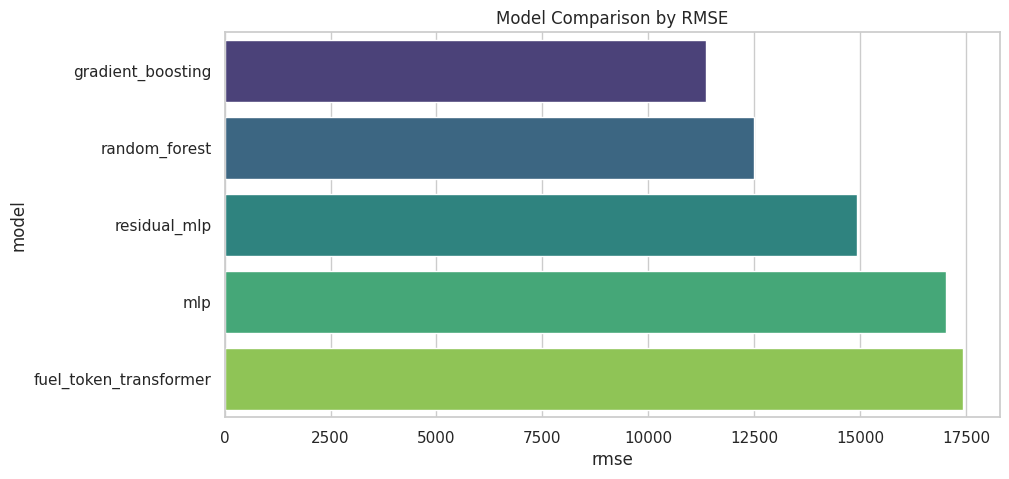

In [19]:
plt.figure(figsize=(10, 5))
plot_df = all_results.sort_values("rmse")
sns.barplot(data=plot_df, x="rmse", y="model", palette="viridis")
plt.title("Model Comparison by RMSE")
plt.show()

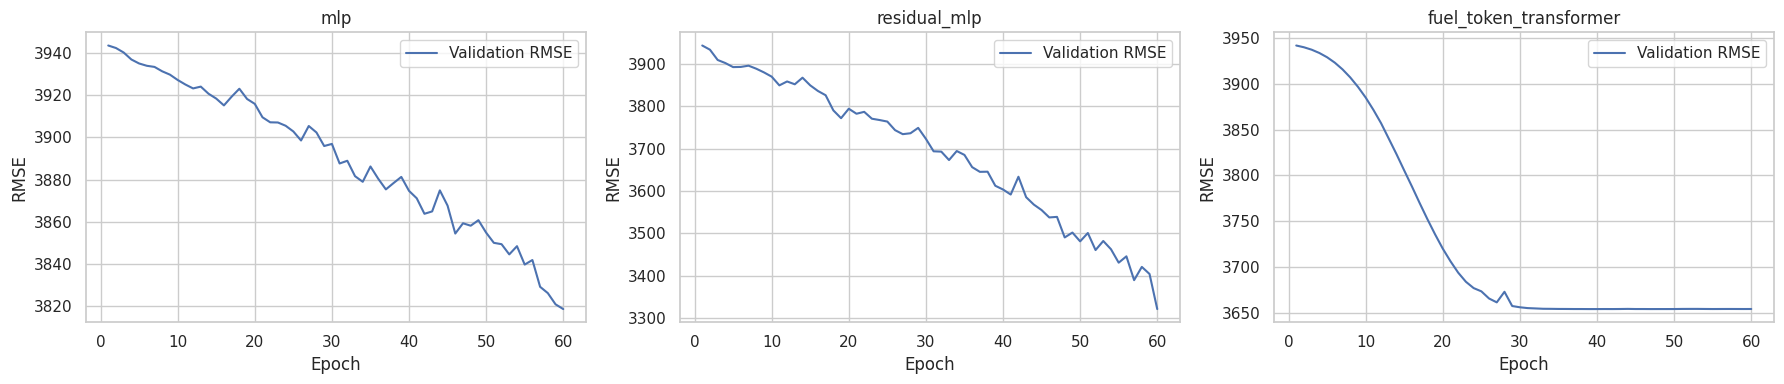

In [20]:
fig, axes = plt.subplots(1, min(len(histories), 3), figsize=(18, 4), squeeze=False)
for ax, (name, hist) in zip(axes[0], histories.items()):
    ax.plot(hist["epoch"], hist["val_rmse"], label="Validation RMSE")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.legend()
plt.tight_layout()
plt.show()

## Subgroup evaluation

The proposal calls for comparing performance across plant types and contexts, so the notebook includes subgroup metrics by primary fuel category, eGRID subregion, and CHP status when those groups have enough observations.

In [21]:
def subgroup_evaluation(df_test, y_true, y_pred):
    evals = []
    group_defs = {
        "primary_fuel_category": "Plant primary fuel category",
        "subregion": "eGRID subregion acronym",
        "chp_flag": "Combined heat and power (CHP) plant adjustment flag",
    }
    for gname, col in group_defs.items():
        if col not in df_test.columns:
            continue
        tmp = pd.DataFrame({"group": df_test[col].fillna("MISSING").astype(str), "y": y_true, "p": y_pred})
        for grp, part in tmp.groupby("group"):
            if len(part) < 15:
                continue
            evals.append({
                "group_type": gname,
                "group": grp,
                "n": len(part),
                **metrics_dict(part["y"], part["p"]),
            })
    return pd.DataFrame(evals)

In [22]:
best_model_name = all_results.iloc[0]["model"]
print("Best model:", best_model_name)

if best_model_name in trained_models:
    if best_model_name == "fuel_token_transformer":
        preds = []
        fte = df_test[fuel_cols].fillna(0).to_numpy(np.float32)
        te_loader = DataLoader(torch.tensor(fte), batch_size=CONFIG["batch_size"], shuffle=False)
        with torch.no_grad():
            for xb in te_loader:
                xb = xb.to(CONFIG["device"])
                preds.append(trained_models[best_model_name](xb).cpu().numpy().ravel())
        best_pred = np.concatenate(preds)
    else:
        best_pred = predict_torch_model(trained_models[best_model_name], test_loader, CONFIG["device"])
else:
    best_sklearn = baseline_models[best_model_name]
    best_sklearn.fit(X_train_full, y_train_full)
    best_pred = best_sklearn.predict(X_test)

subgroup_results = subgroup_evaluation(df_test, yte, best_pred)
subgroup_results.head(20)

Best model: gradient_boosting


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Plant pumped storage flag']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Plant pumped storage flag']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


,group_type,group,n,rmse,mae,r2
0,primary_fuel_category,BIOMASS,127,15.690533,7.450901,0.999366
1,primary_fuel_category,COAL,31,31.880355,24.266007,0.997014
2,primary_fuel_category,GAS,341,113.929001,26.595459,0.997231
3,primary_fuel_category,GEOTHERMAL,15,2.362015,2.361428,0.996816
4,primary_fuel_category,OIL,127,25825.344572,2500.764486,0.562239
5,subregion,AKMS,21,28.638858,21.590853,0.995412
6,subregion,AZNM,24,20.907068,13.406268,0.999807
7,subregion,CAMX,77,17.401633,11.928563,0.999335
8,subregion,ERCT,57,19.153818,13.994679,0.998776
9,subregion,FRCC,18,360.171166,102.780743,0.992375


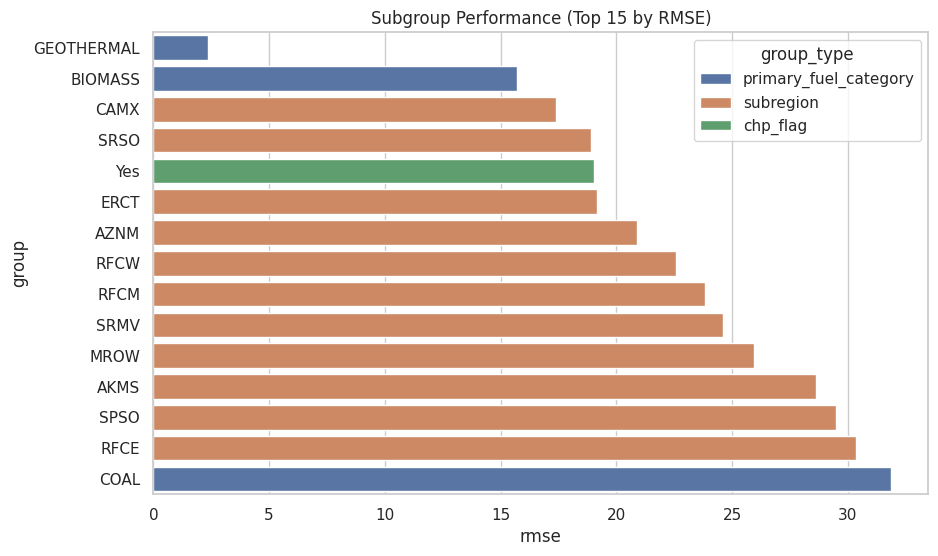

In [23]:
if not subgroup_results.empty:
    top_groups = subgroup_results.sort_values("rmse").head(15)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_groups, x="rmse", y="group", hue="group_type")
    plt.title("Subgroup Performance (Top 15 by RMSE)")
    plt.show()

## Scenario analysis

The proposal specifically motivates counterfactual analysis such as increasing non-combustion generation, activating CHP-related settings, and shifting coal-heavy generation toward gas, all using plant-level variables already present in eGRID.

In [24]:
def run_scenarios(df, prep, trained_model):
    work = df.copy()
    x_num, x_cat = prep.transform(work)
    base_loader = DataLoader(TabularDataset(x_num, x_cat), batch_size=CONFIG["batch_size"], shuffle=False)
    base_pred = predict_torch_model(trained_model, base_loader, CONFIG["device"])
    results = []

    scenarios = {}

    s1 = work.copy()
    if "Plant total noncombustion generation percent (resource mix)" in s1.columns and "Plant total combustion generation percent (resource mix)" in s1.columns:
        s1["Plant total noncombustion generation percent (resource mix)"] = np.clip(
            s1["Plant total noncombustion generation percent (resource mix)"].fillna(0) + 0.10, 0, 1
        )
        s1["Plant total combustion generation percent (resource mix)"] = np.clip(
            s1["Plant total combustion generation percent (resource mix)"].fillna(0) - 0.10, 0, 1
        )
        scenarios["increase_noncombustion_share_10pct"] = s1

    s2 = work.copy()
    if "Combined heat and power (CHP) plant adjustment flag" in s2.columns:
        s2["Combined heat and power (CHP) plant adjustment flag"] = "Yes"
        if "CHP plant useful thermal output (MMBtu)" in s2.columns:
            med = s2["CHP plant useful thermal output (MMBtu)"].replace(0, np.nan).median()
            fill_value = med if pd.notna(med) else 1000
            s2["CHP plant useful thermal output (MMBtu)"] = s2["CHP plant useful thermal output (MMBtu)"].fillna(0).mask(
                s2["CHP plant useful thermal output (MMBtu)"].fillna(0) == 0, fill_value
            )
        scenarios["toggle_chp_on"] = s2

    s3 = work.copy()
    if "Plant coal generation percent (resource mix)" in s3.columns and "Plant gas generation percent (resource mix)" in s3.columns:
        shift = np.minimum(s3["Plant coal generation percent (resource mix)"].fillna(0), 0.20)
        s3["Plant coal generation percent (resource mix)"] = s3["Plant coal generation percent (resource mix)"].fillna(0) - shift
        s3["Plant gas generation percent (resource mix)"] = s3["Plant gas generation percent (resource mix)"].fillna(0) + shift
        if "Plant primary fuel category" in s3.columns:
            s3["Plant primary fuel category"] = s3["Plant primary fuel category"].replace({"COAL": "GAS"})
        scenarios["coal_to_gas_shift_20pct"] = s3

    meta = work[id_cols].copy() if id_cols else pd.DataFrame(index=work.index)
    for name, sdf in scenarios.items():
        x_num_s, x_cat_s = prep.transform(sdf)
        loader = DataLoader(TabularDataset(x_num_s, x_cat_s), batch_size=CONFIG["batch_size"], shuffle=False)
        pred = predict_torch_model(trained_model, loader, CONFIG["device"])
        tmp = meta.copy()
        tmp["scenario"] = name
        tmp["base_prediction"] = base_pred
        tmp["scenario_prediction"] = pred
        tmp["delta"] = pred - base_pred
        results.append(tmp)

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

In [25]:
scenario_results = pd.DataFrame()
if best_model_name in {"mlp", "residual_mlp"}:
    scenario_results = run_scenarios(df_test, prep, trained_models[best_model_name])

scenario_results.head()

""


In [26]:
if not scenario_results.empty:
    summary = scenario_results.groupby("scenario")["delta"].agg(["mean", "median", "min", "max"]).reset_index()
    display(summary)

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=scenario_results, x="scenario", y="delta")
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.xticks(rotation=20)
    plt.title("Scenario Impact on Predicted CO2 Intensity")
    plt.ylabel("Scenario - Base Prediction")
    plt.show()

## Save outputs

This final section exports the comparison tables, subgroup metrics, scenario results, and trained model weights.

In [ ]:
os.makedirs(CONFIG["output_dir"], exist_ok=True)

all_results.to_csv(os.path.join(CONFIG["output_dir"], "model_comparison.csv"), index=False)
subgroup_results.to_csv(os.path.join(CONFIG["output_dir"], "subgroup_metrics.csv"), index=False)
if not scenario_results.empty:
    scenario_results.to_csv(os.path.join(CONFIG["output_dir"], "scenario_analysis.csv"), index=False)

for name, model in trained_models.items():
    if name in {"mlp", "residual_mlp", "fuel_token_transformer"}:
        torch.save(model.state_dict(), os.path.join(CONFIG["output_dir"], f"{name}.pt"))

with open(os.path.join(CONFIG["output_dir"], "run_config.json"), "w") as f:
    json.dump({
        "target_col": CONFIG["target_col"],
        "alt_target_cols": CONFIG["alt_target_cols"],
        "num_cols": num_cols,
        "cat_cols": cat_cols,
        "device": CONFIG["device"],
    }, f, indent=2)

print("Saved outputs to", CONFIG["output_dir"])